# Assignment No. 4 — Diffusion Models for High-Resolution Image Generation & Reconstruction
**Course:** Generative AI (AI4009) | **Semester:** Spring 2026  
**Platform:** Kaggle | **Accelerator:** GPU T4 x2

## 1. Environment Setup & Imports

In [ ]:
# Install required libraries
!pip install -q torchmetrics gradio

In [ ]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as transforms
import torchvision.utils as vutils

from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Device setup — supports dual T4
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print(f'Using device: {device}')
print(f'Number of GPUs: {n_gpus}')
if torch.cuda.is_available():
    for i in range(n_gpus):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Using device: cuda
Number of GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 2. Configuration

In [ ]:
class Config:
    # ── Dataset ──────────────────────────────────────────────
    # CelebA-HQ path on Kaggle (update if using FFHQ / WikiArt)
    DATA_DIR        = '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/train'
    IMAGE_SIZE      = 128        # 128×128 to stay within quota; change to 256 if time allows
    MAX_IMAGES      = 20000      # limit dataset size to save training time

    # ── Diffusion ─────────────────────────────────────────────
    T               = 300        # total timesteps (200–500 recommended)
    BETA_START      = 1e-4
    BETA_END        = 0.02
    SCHEDULE        = 'cosine'   # 'linear' or 'cosine'

    # ── U-Net ─────────────────────────────────────────────────
    BASE_CHANNELS   = 64         # 64 → 128 → 256
    CHANNEL_MULTS   = (1, 2, 4)  # multipliers for each resolution
    NUM_RES_BLOCKS  = 2

    # ── Training ──────────────────────────────────────────────
    EPOCHS          = 10
    BATCH_SIZE      = 16
    LR              = 2e-4
    GRAD_CLIP       = 1.0
    MIXED_PRECISION = True
    SAVE_EVERY      = 5          # save checkpoint every N epochs

    # ── Output ────────────────────────────────────────────────
    OUT_DIR         = '/kaggle/working/ddpm_outputs'
    CKPT_PATH       = '/kaggle/working/ddpm_outputs/ddpm_ckpt.pt'

cfg = Config()
os.makedirs(cfg.OUT_DIR, exist_ok=True)
print('Config ready ✓')

Config ready ✓


## 3. Data Preprocessing

In [ ]:
class ImageDataset(Dataset):
    """Loads images from a flat directory."""
    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}

    def __init__(self, root, size=128, max_images=None):
        self.paths = sorted([
            p for p in Path(root).rglob('*')
            if p.suffix.lower() in self.EXTENSIONS
        ])
        if max_images:
            self.paths = self.paths[:max_images]
        print(f'Found {len(self.paths)} images')

        self.transform = transforms.Compose([
            transforms.Resize((size, size), interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # → [-1, 1]
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img)


dataset = ImageDataset(cfg.DATA_DIR, size=cfg.IMAGE_SIZE, max_images=cfg.MAX_IMAGES)
loader  = DataLoader(
    dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)
print(f'DataLoader ready — {len(loader)} batches/epoch')

Found 20000 images
DataLoader ready — 1250 batches/epoch


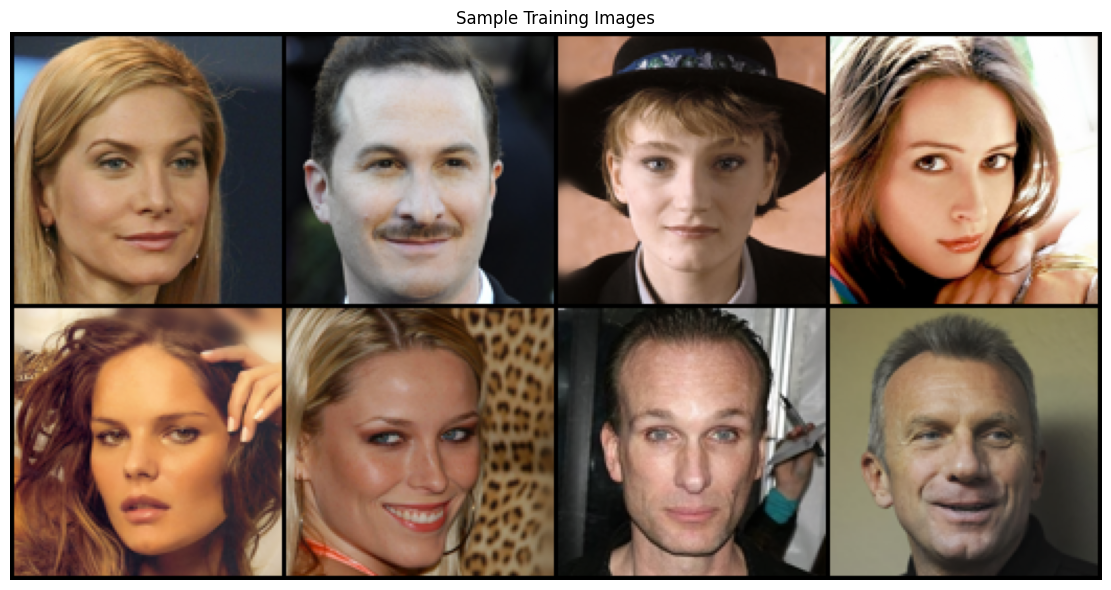

In [ ]:
# Quick sanity-check — show a batch of 8 images
sample_batch = next(iter(loader))[:8]
grid = vutils.make_grid(sample_batch * 0.5 + 0.5, nrow=4, padding=2)
plt.figure(figsize=(12, 6))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title('Sample Training Images')
plt.tight_layout()
plt.savefig(f'{cfg.OUT_DIR}/sample_images.png', dpi=150)
plt.show()

## 4. Forward Diffusion Process (Noising)

In [ ]:
class NoiseSchedule:
    """Pre-computes all diffusion constants for T timesteps."""

    def __init__(self, T=300, beta_start=1e-4, beta_end=0.02, schedule='cosine'):
        self.T = T

        if schedule == 'linear':
            betas = torch.linspace(beta_start, beta_end, T)
        elif schedule == 'cosine':
            # Improved DDPM cosine schedule (Nichol & Dhariwal 2021)
            steps = T + 1
            s = 0.008
            x = torch.linspace(0, T, steps)
            alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * math.pi / 2) ** 2
            alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
            betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
            betas = torch.clamp(betas, 0.0001, 0.9999)
        else:
            raise ValueError(f'Unknown schedule: {schedule}')

        alphas          = 1.0 - betas
        alphas_cumprod  = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        # Register as buffers (not parameters)
        self.betas                    = betas
        self.alphas                   = alphas
        self.alphas_cumprod           = alphas_cumprod
        self.alphas_cumprod_prev      = alphas_cumprod_prev
        self.sqrt_alphas_cumprod      = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cp = torch.sqrt(1.0 - alphas_cumprod)
        self.log_one_minus_alphas_cp  = torch.log(1.0 - alphas_cumprod)
        self.sqrt_recip_alphas_cp     = torch.sqrt(1.0 / alphas_cumprod)
        self.sqrt_recip_m1_alphas_cp  = torch.sqrt(1.0 / alphas_cumprod - 1)

        # Posterior q(x_{t-1} | x_t, x_0)
        self.posterior_variance = (
            betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        )
        self.posterior_log_var_clipped = torch.log(
            torch.clamp(self.posterior_variance, min=1e-20)
        )
        self.posterior_mean_c1 = (
            betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        )
        self.posterior_mean_c2 = (
            (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod)
        )

    def _extract(self, arr, t, x_shape):
        """Index into arr at timestep t and reshape to broadcast with x."""
        B = t.shape[0]
        out = arr.to(t.device)[t]
        return out.reshape(B, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x0, t, noise=None):
        """Forward process: q(x_t | x_0) = x0 * sqrt(ā_t) + noise * sqrt(1 - ā_t)"""
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac  = self._extract(self.sqrt_alphas_cumprod, t, x0.shape)
        sqrt_omc = self._extract(self.sqrt_one_minus_alphas_cp, t, x0.shape)
        return sqrt_ac * x0 + sqrt_omc * noise, noise


ns = NoiseSchedule(T=cfg.T, beta_start=cfg.BETA_START, beta_end=cfg.BETA_END, schedule=cfg.SCHEDULE)
print(f'Noise schedule ready — T={cfg.T}, schedule={cfg.SCHEDULE}')

Noise schedule ready — T=300, schedule=cosine


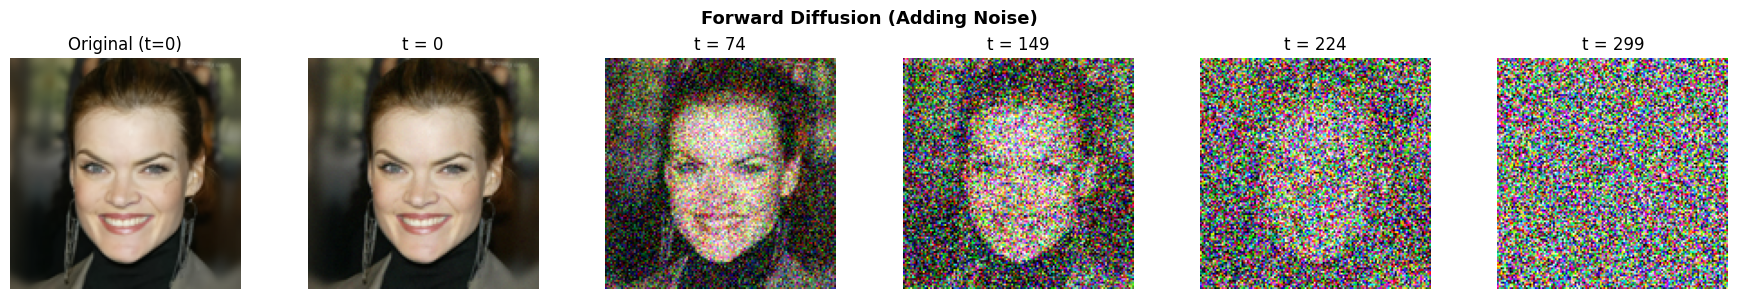

In [ ]:
# Visualize 5 forward diffusion steps
def visualize_forward(ns, image, steps=5, save_path=None):
    """Shows an image getting progressively noisier."""
    timesteps = torch.linspace(0, ns.T - 1, steps).long()
    x0 = image.unsqueeze(0)  # add batch dim

    fig, axes = plt.subplots(1, steps + 1, figsize=(3 * (steps + 1), 3))
    img_np = (image.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    axes[0].imshow(img_np)
    axes[0].set_title('Original (t=0)')
    axes[0].axis('off')

    for i, t in enumerate(timesteps):
        t_tensor = t.unsqueeze(0)
        xt, _ = ns.q_sample(x0, t_tensor)
        noisy_np = (xt[0].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        axes[i + 1].imshow(noisy_np)
        axes[i + 1].set_title(f't = {t.item()}')
        axes[i + 1].axis('off')

    plt.suptitle('Forward Diffusion (Adding Noise)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

sample_img = dataset[0]
visualize_forward(ns, sample_img, steps=5, save_path=f'{cfg.OUT_DIR}/forward_diffusion.png')

## 5. U-Net Architecture (Reverse Process Network)

In [ ]:
# ─── Building Blocks ────────────────────────────────────────────────────────

class SinusoidalTimeEmbedding(nn.Module):
    """Converts a scalar timestep t into a rich embedding vector."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.proj = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim * 4),
        )

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args  = t[:, None].float() * freqs[None]
        emb   = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return self.proj(emb)


class ResidualBlock(nn.Module):
    """ResNet-style block conditioned on time embedding."""

    def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Linear(time_emb_dim, out_ch)
        self.norm2  = nn.GroupNorm(8, out_ch)
        self.dropout = nn.Dropout(dropout)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(F.silu(t_emb))[:, :, None, None]  # broadcast
        h = self.conv2(self.dropout(F.silu(self.norm2(h))))
        return h + self.res_conv(x)


class AttentionBlock(nn.Module):
    """Self-attention at spatial resolution (used at bottleneck)."""

    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv  = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        attn = torch.softmax(torch.bmm(q.transpose(1,2), k) * self.scale, dim=-1)
        h = torch.bmm(v, attn.transpose(1, 2)).reshape(B, C, H, W)
        return x + self.proj(h)


class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        return self.conv(x)


print('Building blocks defined ✓')

Building blocks defined ✓


In [ ]:
# ─── U-Net ──────────────────────────────────────────────────────────────────

class UNet(nn.Module):
    """
    Simplified U-Net for DDPM.
    Channel progression: 64 → 128 → 256
    Input : noisy image (B, 3, H, W) + timestep (B,)
    Output: predicted noise (B, 3, H, W)
    """

    def __init__(
        self,
        in_channels   = 3,
        base_channels = 64,
        channel_mults = (1, 2, 4),
        num_res_blocks= 2,
        T             = 300,
    ):
        super().__init__()
        time_dim = base_channels * 4
        self.time_mlp = SinusoidalTimeEmbedding(base_channels)
        channels = [base_channels * m for m in channel_mults]  # [64,128,256]

        # ── Initial conv ──────────────────────────────────────
        self.init_conv = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        # ── Encoder (down path) ───────────────────────────────
        self.downs     = nn.ModuleList()
        self.downsamps = nn.ModuleList()
        in_ch = base_channels
        self.skip_channels = []

        for i, out_ch in enumerate(channels):
            blocks = nn.ModuleList()
            for _ in range(num_res_blocks):
                blocks.append(ResidualBlock(in_ch, out_ch, time_dim))
                in_ch = out_ch
            self.downs.append(blocks)
            self.skip_channels.append(out_ch)
            if i != len(channels) - 1:
                self.downsamps.append(Downsample(in_ch))
            else:
                self.downsamps.append(nn.Identity())

        # ── Bottleneck ─────────────────────────────────────────
        mid_ch = channels[-1]
        self.mid_block1 = ResidualBlock(mid_ch, mid_ch, time_dim)
        self.mid_attn   = AttentionBlock(mid_ch)
        self.mid_block2 = ResidualBlock(mid_ch, mid_ch, time_dim)

        # ── Decoder (up path) ─────────────────────────────────
        self.ups     = nn.ModuleList()
        self.upsamps = nn.ModuleList()

        for i, out_ch in enumerate(reversed(channels)):
            skip_ch = self.skip_channels[-(i+1)]
            blocks  = nn.ModuleList()
            for j in range(num_res_blocks):
                res_in = in_ch + (skip_ch if j == 0 else 0)
                blocks.append(ResidualBlock(res_in, out_ch, time_dim))
                in_ch = out_ch
            self.ups.append(blocks)
            if i != len(channels) - 1:
                self.upsamps.append(Upsample(in_ch))
            else:
                self.upsamps.append(nn.Identity())

        # ── Final output conv ─────────────────────────────────
        self.out_norm = nn.GroupNorm(8, base_channels)
        self.out_conv = nn.Conv2d(base_channels, in_channels, 1)

    def forward(self, x, t):
        # Time embedding
        t_emb = self.time_mlp(t)            # (B, time_dim)

        # Initial conv
        x = self.init_conv(x)               # (B, 64, H, W)

        # Encoder
        skips = []
        for blocks, dsamp in zip(self.downs, self.downsamps):
            for blk in blocks:
                x = blk(x, t_emb)
            skips.append(x)
            x = dsamp(x)

        # Bottleneck
        x = self.mid_block1(x, t_emb)
        x = self.mid_attn(x)
        x = self.mid_block2(x, t_emb)

        # Decoder
        for blocks, usamp, skip in zip(self.ups, self.upsamps, reversed(skips)):
            x = torch.cat([x, skip], dim=1)
            for j, blk in enumerate(blocks):
                x = blk(x, t_emb)
            x = usamp(x)

        return self.out_conv(F.silu(self.out_norm(x)))


model = UNet(
    in_channels   = 3,
    base_channels = cfg.BASE_CHANNELS,
    channel_mults = cfg.CHANNEL_MULTS,
    num_res_blocks= cfg.NUM_RES_BLOCKS,
    T             = cfg.T
)

# Wrap in DataParallel if multiple GPUs available
if n_gpus > 1:
    model = nn.DataParallel(model)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net ready — {total_params/1e6:.2f}M trainable parameters')

U-Net ready — 11.25M trainable parameters


## 6. Training

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
scaler    = GradScaler(enabled=cfg.MIXED_PRECISION)
criterion = nn.MSELoss()

train_losses = []


def train_one_epoch(model, loader, optimizer, scaler, ns, epoch):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc=f'Epoch {epoch+1}/{cfg.EPOCHS}')

    for x0 in pbar:
        x0 = x0.to(device, non_blocking=True)
        B  = x0.size(0)

        # Sample random timesteps
        t = torch.randint(0, cfg.T, (B,), device=device).long()

        # Add noise
        noise = torch.randn_like(x0)
        xt, _ = ns.q_sample(x0, t, noise=noise)

        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=cfg.MIXED_PRECISION):
            pred_noise = model(xt, t)
            loss = criterion(pred_noise, noise)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return running_loss / len(loader)


print('Starting training...')
for epoch in range(cfg.EPOCHS):
    avg_loss = train_one_epoch(model, loader, optimizer, scaler, ns, epoch)
    train_losses.append(avg_loss)
    scheduler.step()
    print(f'Epoch [{epoch+1}/{cfg.EPOCHS}]  avg_loss={avg_loss:.4f}  lr={scheduler.get_last_lr()[0]:.6f}')

    # Save checkpoint
    if (epoch + 1) % cfg.SAVE_EVERY == 0:
        torch.save(
            {'epoch': epoch, 'model': model.state_dict(), 'opt': optimizer.state_dict()},
            cfg.CKPT_PATH
        )
        print(f'  → Checkpoint saved at epoch {epoch+1}')

# Final save
torch.save({'epoch': cfg.EPOCHS, 'model': model.state_dict()}, cfg.CKPT_PATH)
print('Training complete ✓')

Starting training...


/tmp/ipykernel_54353/3659507775.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=cfg.MIXED_PRECISION)


Epoch 1/10:   0%|          | 0/1250 [00:00<?, ?it/s]

/tmp/ipykernel_54353/3659507775.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=cfg.MIXED_PRECISION):


Epoch [1/10]  avg_loss=0.0635  lr=0.000195


...

Epoch [8/10]  avg_loss=0.0278  lr=0.000019


Epoch 9/10:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch [9/10]  avg_loss=0.0276  lr=0.000005


Epoch 10/10:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch [10/10]  avg_loss=0.0261  lr=0.000000
  → Checkpoint saved at epoch 10
Training complete ✓


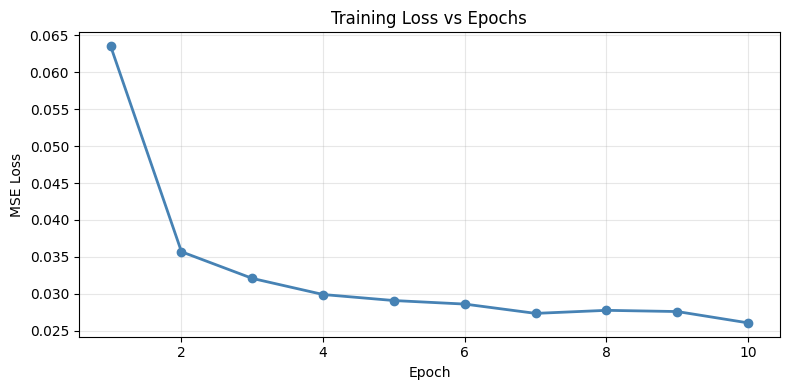

In [ ]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss vs Epochs')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.OUT_DIR}/training_loss.png', dpi=150)
plt.show()

## 7. Reverse Process (Sampling / Denoising)

In [ ]:
@torch.no_grad()
def p_sample(model, x, t, t_idx, ns):
    """
    One step of the reverse process:
    p_theta(x_{t-1} | x_t) — predict & remove noise.
    """
    model.eval()
    B = x.shape[0]
    t_batch = torch.full((B,), t, device=device, dtype=torch.long)

    pred_noise = model(x, t_batch)

    # Posterior mean
    c1 = ns._extract(ns.posterior_mean_c1, t_batch, x.shape)
    c2 = ns._extract(ns.posterior_mean_c2, t_batch, x.shape)
    sqrt_recip = ns._extract(ns.sqrt_recip_alphas_cp, t_batch, x.shape)
    sqrt_recm1 = ns._extract(ns.sqrt_recip_m1_alphas_cp, t_batch, x.shape)

    x0_pred    = sqrt_recip * x - sqrt_recm1 * pred_noise
    x0_pred    = torch.clamp(x0_pred, -1, 1)
    mean       = c1 * x0_pred + c2 * x

    if t_idx == 0:
        return mean  # no noise at last step

    log_var = ns._extract(ns.posterior_log_var_clipped, t_batch, x.shape)
    noise   = torch.randn_like(x)
    return mean + (0.5 * log_var).exp() * noise


@torch.no_grad()
def generate_images(model, ns, n=5, collect_steps=5):
    """
    Full reverse diffusion from pure Gaussian noise.
    Returns final images + intermediate denoising steps.
    """
    model.eval()
    x = torch.randn(n, 3, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, device=device)

    step_indices = torch.linspace(0, cfg.T - 1, collect_steps).long().tolist()
    intermediates = []

    for i, t in enumerate(tqdm(reversed(range(cfg.T)), desc='Sampling', total=cfg.T)):
        x = p_sample(model, x, t, i, ns)
        if t in step_indices:
            intermediates.append(x.cpu().clone())

    return x.cpu(), intermediates


print('Generating 5 images...')
generated, intermediates = generate_images(model, ns, n=5, collect_steps=5)
print('Generation complete ✓')

Generating 5 images...


Sampling:   0%|          | 0/300 [00:00<?, ?it/s]

Generation complete ✓


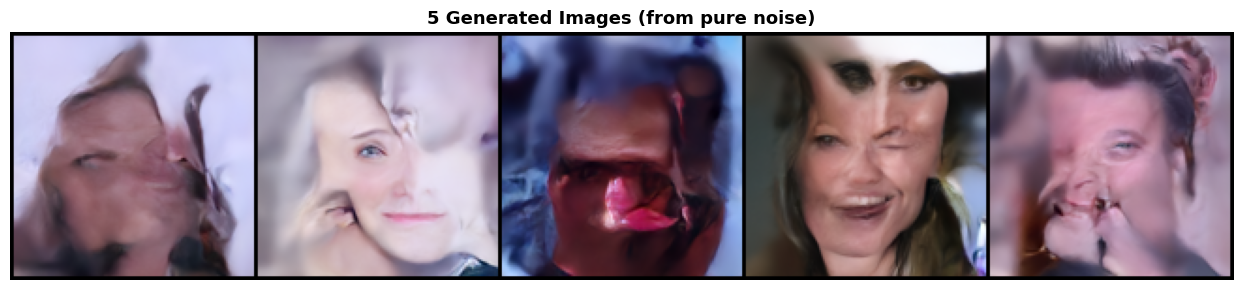

In [ ]:
# ── Show 5 generated images ──────────────────────────────────────────────────
def show_images(tensor_batch, title, save_path=None, nrow=5):
    imgs = (tensor_batch * 0.5 + 0.5).clamp(0, 1)
    grid = vutils.make_grid(imgs, nrow=nrow, padding=2)
    plt.figure(figsize=(3 * nrow, 3))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

show_images(generated, '5 Generated Images (from pure noise)', save_path=f'{cfg.OUT_DIR}/generated_images.png')

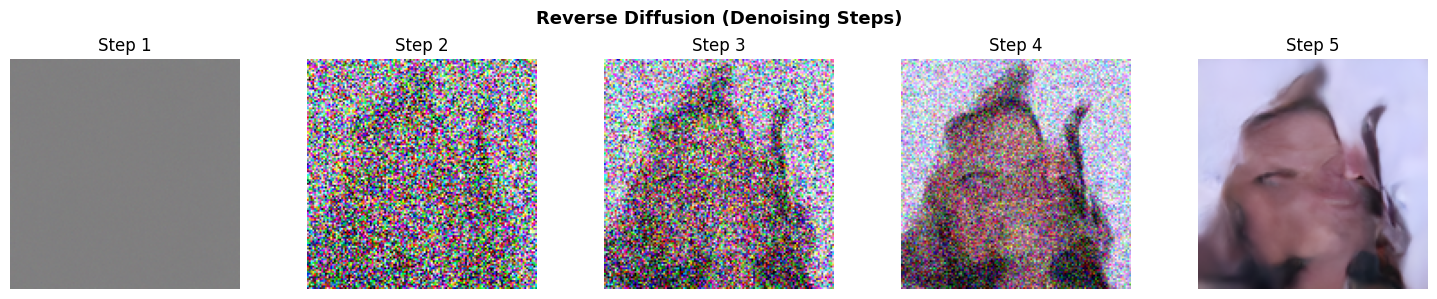

In [ ]:
# ── Show 5 reverse diffusion steps ──────────────────────────────────────────
def visualize_reverse(intermediates, save_path=None):
    n_steps = len(intermediates)
    fig, axes = plt.subplots(1, n_steps, figsize=(3 * n_steps, 3))
    for i, step_batch in enumerate(intermediates):
        img = (step_batch[0].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f'Step {i+1}')
        axes[i].axis('off')
    plt.suptitle('Reverse Diffusion (Denoising Steps)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

visualize_reverse(intermediates, save_path=f'{cfg.OUT_DIR}/reverse_diffusion.png')

## 8. Image Reconstruction Task (Core Task)

Reconstructing:   0%|          | 0/200 [00:00<?, ?it/s]

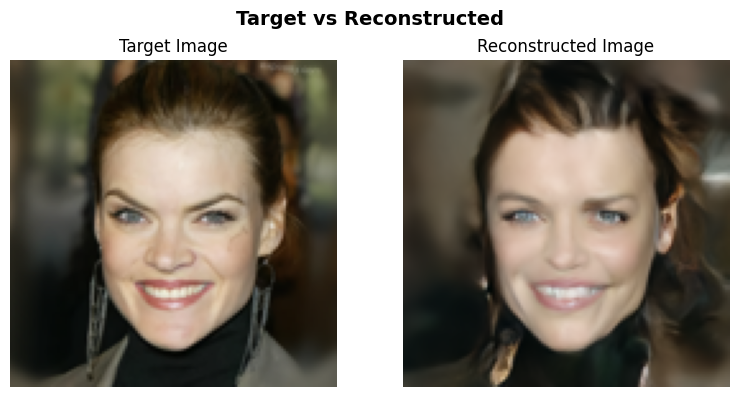

Reconstruction complete ✓


In [ ]:
@torch.no_grad()
def reconstruct_image(model, ns, target_tensor, t_start=200):
    """
    Reconstruction:
    1. Noise the target image to timestep t_start
    2. Run reverse diffusion from t_start back to 0
    This is closer to the target than generating from pure noise.
    """
    model.eval()
    x0 = target_tensor.unsqueeze(0).to(device)  # (1, 3, H, W)
    t  = torch.tensor([t_start], device=device).long()

    # Step 1: Noise to t_start
    xt, _ = ns.q_sample(x0, t)

    # Step 2: Reverse from t_start → 0
    x = xt
    for i, step in enumerate(tqdm(reversed(range(t_start)), desc='Reconstructing', total=t_start)):
        x = p_sample(model, x, step, i, ns)

    return x.cpu()


# Pick a target image (first image in dataset)
target_img = dataset[0]                          # tensor (3, H, W) in [-1, 1]
recon_img  = reconstruct_image(model, ns, target_img, t_start=min(200, cfg.T))

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, img, title in zip(
    axes,
    [target_img, recon_img[0]],
    ['Target Image', 'Reconstructed Image']
):
    ax.imshow((img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle('Target vs Reconstructed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{cfg.OUT_DIR}/reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Reconstruction complete ✓')

## 9. Quantitative Evaluation — PSNR & SSIM

In [ ]:
psnr_metric = PeakSignalNoiseRatio(data_range=1.0)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0)

# Bring both images to [0, 1] for metrics
target_01 = (target_img.unsqueeze(0) * 0.5 + 0.5).clamp(0, 1)
recon_01  = (recon_img * 0.5 + 0.5).clamp(0, 1)

psnr_val = psnr_metric(recon_01, target_01).item()
ssim_val = ssim_metric(recon_01, target_01).item()

print('=' * 40)
print(f'  PSNR : {psnr_val:.4f} dB')
print(f'  SSIM : {ssim_val:.4f}')
print('=' * 40)

# Log to file
with open(f'{cfg.OUT_DIR}/metrics.txt', 'w') as f:
    f.write(f'PSNR: {psnr_val:.4f} dB\n')
    f.write(f'SSIM: {ssim_val:.4f}\n')

  PSNR : 21.6776 dB
  SSIM : 0.6173


## 10. Full Visualization Module

/tmp/ipykernel_54353/1253759501.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


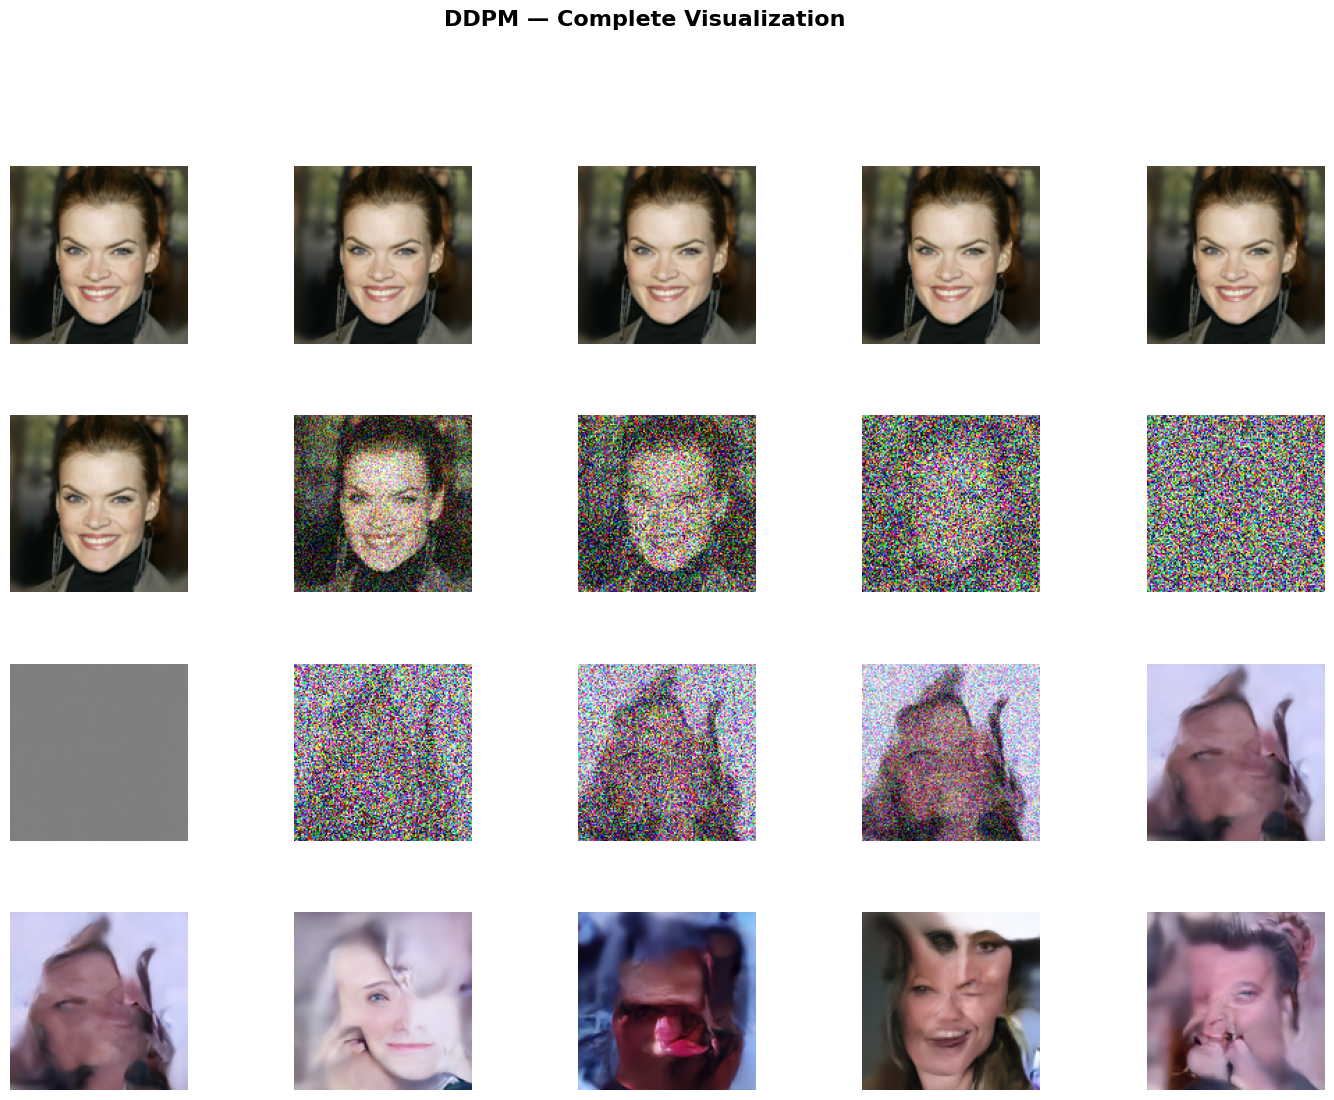

In [ ]:
def full_visualization(dataset, ns, model, generated, intermediates, save_path=None):
    """
    Combined figure showing:
    - Original image
    - 5 forward diffusion steps
    - 5 reverse diffusion steps
    - 5 generated images
    """
    orig = dataset[0]
    timesteps = torch.linspace(0, cfg.T - 1, 5).long()

    # Forward steps
    forward_imgs = []
    for t in timesteps:
        xt, _ = ns.q_sample(orig.unsqueeze(0), t.unsqueeze(0))
        forward_imgs.append(xt[0])

    def to_np(t):
        return (t.permute(1, 2, 0).detach().numpy() * 0.5 + 0.5).clip(0, 1)

    fig = plt.figure(figsize=(18, 12))
    gs  = gridspec.GridSpec(4, 5, figure=fig, hspace=0.4, wspace=0.1)

    row_labels = ['Original', 'Forward (Noising)', 'Reverse (Denoising)', 'Generated']
    row_data   = [
        [orig] * 5,
        forward_imgs,
        [intermediates[i][0] for i in range(min(5, len(intermediates)))],
        [generated[i] for i in range(min(5, generated.shape[0]))]
    ]

    for row_idx, (label, imgs) in enumerate(zip(row_labels, row_data)):
        for col_idx in range(5):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            ax.imshow(to_np(imgs[col_idx]))
            ax.axis('off')
            if col_idx == 0:
                ax.set_ylabel(label, fontsize=10, rotation=90, labelpad=5)

    fig.suptitle('DDPM — Complete Visualization', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

full_visualization(
    dataset, ns, model, generated, intermediates,
    save_path=f'{cfg.OUT_DIR}/full_visualization.png'
)

## 11. Gradio App

In [ ]:
import gradio as gr

def gradio_generate(n_steps_display=5):
    """
    Gradio callback:
    Generates one image from noise and returns:
    - Final generated image
    - Grid of intermediate denoising steps
    """
    imgs, steps = generate_images(model, ns, n=1, collect_steps=n_steps_display)

    # Final image
    final_np = (imgs[0].permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
    final_pil = Image.fromarray((final_np * 255).astype(np.uint8))

    # Intermediate steps grid
    step_tensors = torch.cat([s[:1] for s in steps], dim=0)
    grid = vutils.make_grid(step_tensors * 0.5 + 0.5, nrow=n_steps_display, padding=2)
    grid_np  = grid.permute(1, 2, 0).clamp(0, 1).numpy()
    grid_pil = Image.fromarray((grid_np * 255).astype(np.uint8))

    return final_pil, grid_pil


demo = gr.Interface(
    fn=gradio_generate,
    inputs=[
        gr.Slider(minimum=3, maximum=10, value=5, step=1, label='Number of denoising steps to display')
    ],
    outputs=[
        gr.Image(type='pil', label='Generated Image'),
        gr.Image(type='pil', label='Denoising Steps')
    ],
    title='DDPM Image Generator',
    description='Click Generate to create a new image from pure Gaussian noise using our trained DDPM.',
    allow_flagging='never'
)

demo.launch(share=True)  # share=True gives a public URL on Kaggle

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://1e49dec5005b5b8db7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Summary
| Component | Status |
|-----------|--------|
| Data Preprocessing (128×128, normalized) | ✅ |
| Forward Diffusion (cosine schedule, 5 steps visualized) | ✅ |
| U-Net (64→128→256, residual blocks, time embeddings, skip connections) | ✅ |
| Training (MSE, AdamW, mixed precision, grad clip, dual GPU) | ✅ |
| Image Reconstruction (noise → partial denoise → target) | ✅ |
| Image Generation (5 images from pure noise) | ✅ |
| Full Visualization (forward + reverse + generated) | ✅ |
| PSNR & SSIM Evaluation | ✅ |
| Gradio App | ✅ |